In [ ]:
# NOTE: eventually this should be merged with 1b.level1_to_level2-edp2 so that processing is entirely uniform across the two cohorts
# at the moment, the edp2 files are processed using the good genes from this file
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import h5py, glob, re, os, gc, pickle, scipy.sparse, time
from shapely.geometry import Point, Polygon
import shapely
import glob, gc
import geopandas as gpd

basedir = '/data/srlab/AMP_collab/data/early_disease_synovium/'
xeniumdir = f'{basedir}/xenium'

In [2]:
metadata = pd.concat([
    pd.read_csv(f'{basedir}/Xenium_CTRL-SYN-EDP1_assay manifest.csv').assign(subset="CTRL"),
    pd.read_csv(f'{basedir}/Xenium_RA-SYN-EDP1_assay manifest.csv').assign(subset="RA"),
    pd.read_csv(f'{basedir}/Xenium_PsD-SYN-EDP1_assay manifest.csv').assign(subset="PsD")
]).set_index('Sample_ID')

In [3]:
def read(slide_id):
    print('reading', slide_id)
    subset = metadata[metadata['Xenium-Slide_Sample_ID'] == slide_id].subset.iloc[0]
    path = glob.glob(f'{xeniumdir}/Xenium_{subset}-SYN-EDP1/Level_1_Xenium_Output/*{slide_id}*')[0]
    transcripts = pd.read_parquet(f'{path}/transcripts.parquet', engine='fastparquet')
    gene_transcripts = transcripts[transcripts.is_gene]
    return gene_transcripts[gene_transcripts.qv >= 20], subset, path

# Define sample polygons for each slide

In [89]:
def annotate(slide_id, polygons, names, save=True, figw=5):
    for name in names:
        if metadata.loc[name, 'Xenium-Slide_Sample_ID'] != slide_id:
            print('ERROR: sample id doesnt match slide')
            print('got:', name)
            print('samples on slide are:', metadata[metadata['Xenium-Slide_Sample_ID'] == slide_id].index)
            return
    
    tx, subset, path = read(slide_id)
    print(subset)
    ix = np.random.choice(len(tx), 50000, replace=False)

    plt.figure(figsize=(figw,figw))
    plt.scatter(tx.iloc[ix].x_location, tx.iloc[ix].y_location, s=1, alpha=0.3)
    polygon = polygons[0]; name = names[0]
    plt.plot(*np.array(polygon.exterior.coords).T)
    plt.text(polygon.centroid.x, polygon.centroid.y, name, ha='center', va='center', fontsize=12, color='red')
    if len(polygons) > 1:
        polygon = polygons[1]; name = names[1]
        plt.plot(*np.array(polygon.exterior.coords).T)
        plt.text(polygon.centroid.x, polygon.centroid.y, name, ha='center', va='center', fontsize=12, color='red')    
    plt.axis('equal')
    plt.show()
    
    if save:
        data = {
            'sampleID': names,
            'slideID' : [slide_id] * len(names)
        }
        gdf = gpd.GeoDataFrame(
            data,
            geometry=polygons,
            crs=None)
        gdf.attrs['name'] = f'xenium_bbox_synovium_{slide_id}'
        target = f'{xeniumdir}/Xenium_{subset}-SYN-EDP1/Level_2/'
        os.makedirs(target, exist_ok=True)
        gdf.to_file(f'{target}/xenium_bbox_synovium_{slide_id}.geojson', driver='GeoJSON')

reading slidearray0097
RA


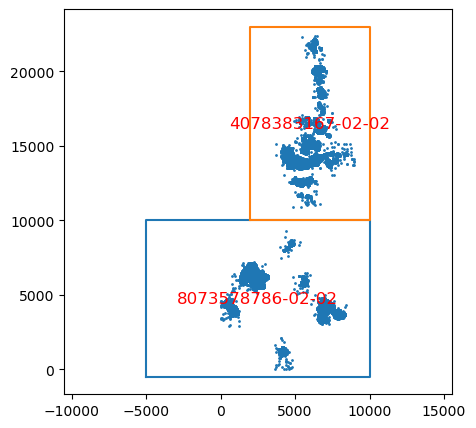

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [49]:
slide_id = 'slidearray0097'
s1 = Polygon([(-5000, -500), (-5000, 10000), (10000, 10000), (10000, -500)])
s1name = '8073578786-02-02'
s2 = Polygon([(2000, 10000), (2000, 23000), (10000, 23000), (10000, 10000)])
s2name = '4078383167-02-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0093
RA


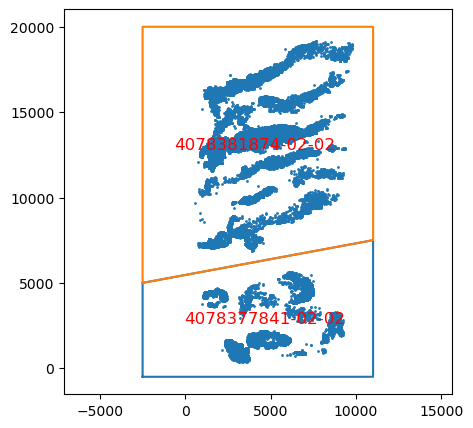

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [57]:
slide_id = 'slidearray0093'
s1 = Polygon([(-2500, -500), (-2500, 5000), (11000, 7500), (11000, -500)])
s1name = '4078377841-02-02'
s2 = Polygon([(-2500, 5000), (-2500, 20000), (11000, 20000), (11000, 7500)])
s2name = '4078381874-02-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0085
RA


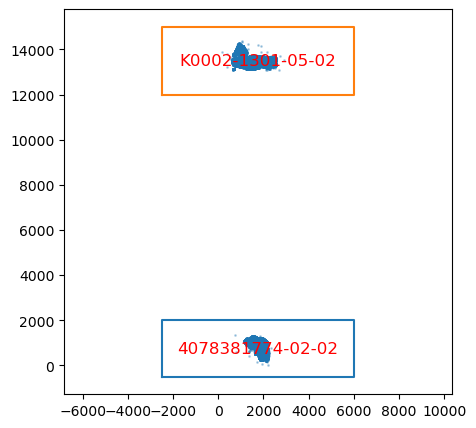

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [62]:
slide_id = 'slidearray0085'
s1 = Polygon([(-2500, -500), (-2500, 2000), (6000, 2000), (6000, -500)])
s1name = '4078381774-02-02'
s2 = Polygon([(-2500, 12000), (-2500, 15000), (6000, 15000), (6000, 12000)])
s2name = 'K0002-1301-05-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0095
RA


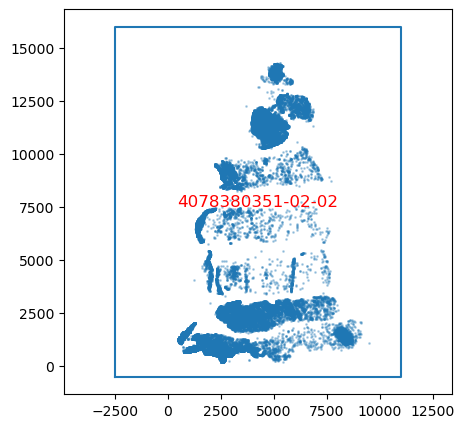

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [66]:
slide_id = 'slidearray0095'
s1 = Polygon([(-2500, -500), (-2500, 16000), (11000, 16000), (11000, -500)])
s1name = '4078380351-02-02'
annotate(slide_id, [s1], [s1name])

reading slidearray0099
RA


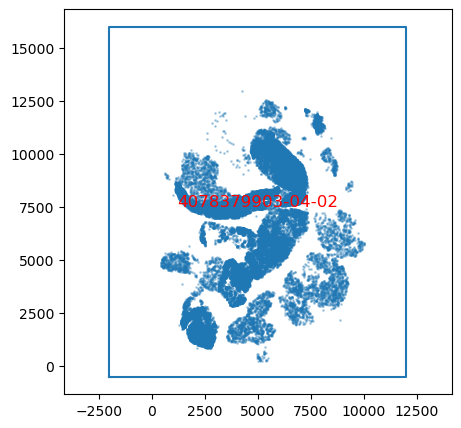

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [68]:
slide_id = 'slidearray0099'
s1 = Polygon([(-2000, -500), (-2000, 16000), (12000, 16000), (12000, -500)])
s1name = '4078379903-04-02'
annotate(slide_id, [s1], [s1name])

reading slidearray0091
RA


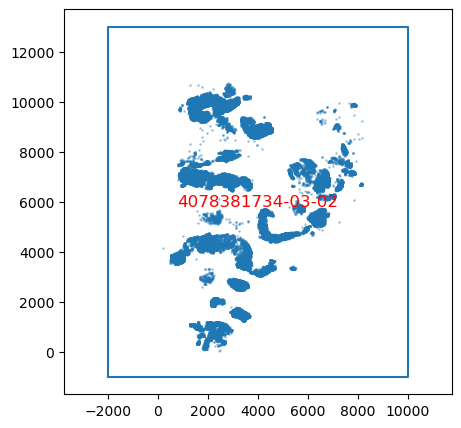

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [69]:
slide_id = 'slidearray0091'
s1 = Polygon([(-2000, -1000), (-2000, 13000), (10000, 13000), (10000, -1000)])
s1name = '4078381734-03-02'
annotate(slide_id, [s1], [s1name])

reading slidearray0089
RA


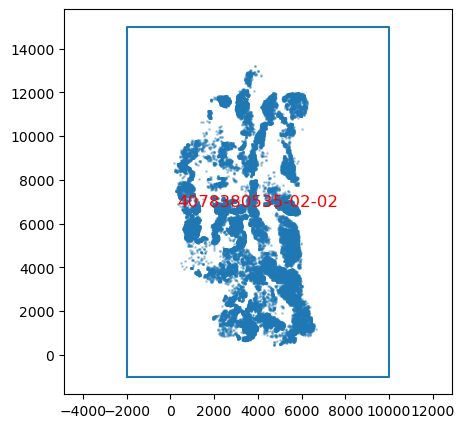

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [70]:
slide_id = 'slidearray0089'
s1 = Polygon([(-2000, -1000), (-2000, 15000), (10000, 15000), (10000, -1000)])
s1name = '4078380535-02-02'
annotate(slide_id, [s1], [s1name])

reading slidearray0081
RA


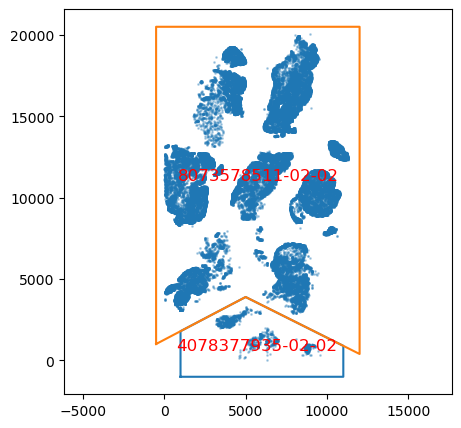

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [74]:
slide_id = 'slidearray0081'
s1 = Polygon([(1000, -1000), (1000, 1800), (5000, 3900), (11000, 900), (11000, -1000)])
s1name = '4078377935-02-02'
s2 = Polygon([(-500, 1012.5), (-500, 20500), (12000, 20500), (12000, 400), (5000, 3900)])
s2name = '8073578511-02-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0083
RA


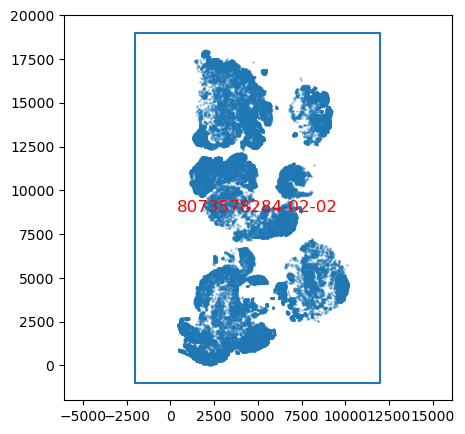

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [75]:
slide_id = 'slidearray0083'
s1 = Polygon([(-2000, -1000), (-2000, 19000), (12000, 19000), (12000, -1000)])
s1name = '8073578284-02-02'
annotate(slide_id, [s1], [s1name])

reading slidearray0114
PsD


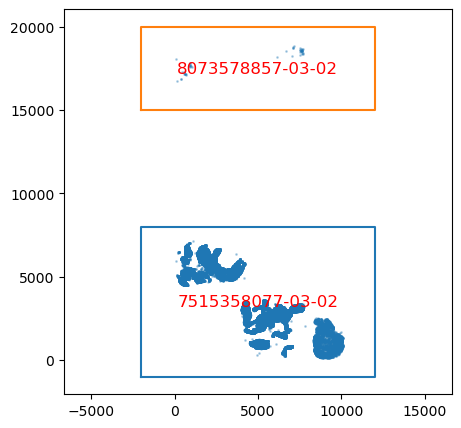

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [85]:
slide_id = 'slidearray0114'
s1 = Polygon([(-2000, -1000), (-2000, 8000), (12000, 8000), (12000, -1000)])
s1name = '7515358077-03-02'
s2 = Polygon([(-2000, 15000), (-2000, 20000), (12000, 20000), (12000, 15000)])
s2name = '8073578857-03-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0112
PsD


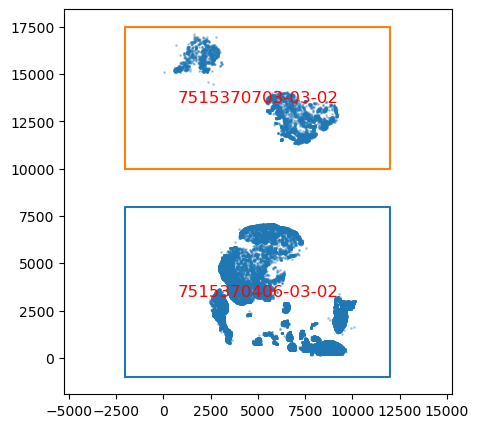

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [86]:
slide_id = 'slidearray0112'
s1 = Polygon([(-2000, -1000), (-2000, 8000), (12000, 8000), (12000, -1000)])
s1name = '7515370406-03-02'
s2 = Polygon([(-2000, 10000), (-2000, 17500), (12000, 17500), (12000, 10000)])
s2name = '7515370703-03-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0108
PsD


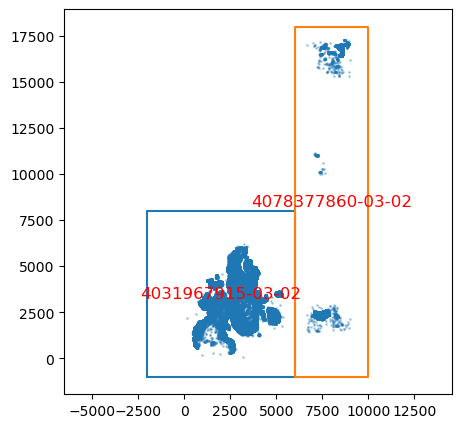

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [91]:
slide_id = 'slidearray0108'
s1 = Polygon([(-2000, -1000), (-2000, 8000), (6000, 8000), (6000, -1000)])
s1name = '4031967915-03-02'
s2 = Polygon([(6000, -1000), (6000, 18000), (10000, 18000), (10000, -1000)])
s2name = '4078377860-03-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0110
PsD


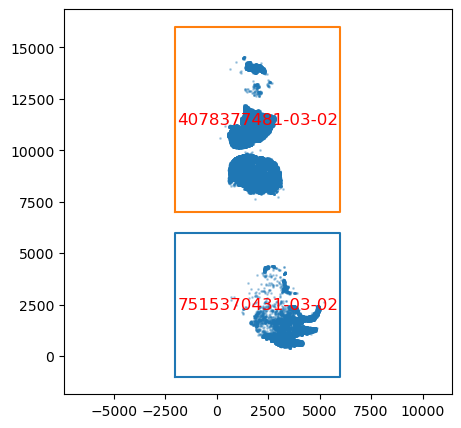

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [92]:
slide_id = 'slidearray0110'
s1 = Polygon([(-2000, -1000), (-2000, 6000), (6000, 6000), (6000, -1000)])
s1name = '7515370431-03-02'
s2 = Polygon([(-2000, 7000), (-2000, 16000), (6000, 16000), (6000, 7000)])
s2name = '4078377481-03-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0104
CTRL


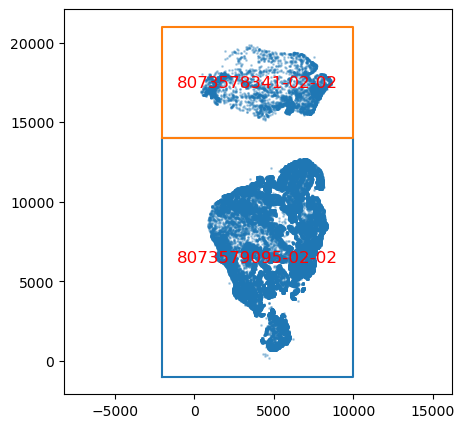

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [94]:
slide_id = 'slidearray0104'
s1 = Polygon([(-2000, -1000), (-2000, 14000), (10000, 14000), (10000, -1000)])
s1name = '8073579095-02-02'
s2 = Polygon([(-2000, 14000), (-2000, 21000), (10000, 21000), (10000, 14000)])
s2name = '8073578341-02-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0106
CTRL


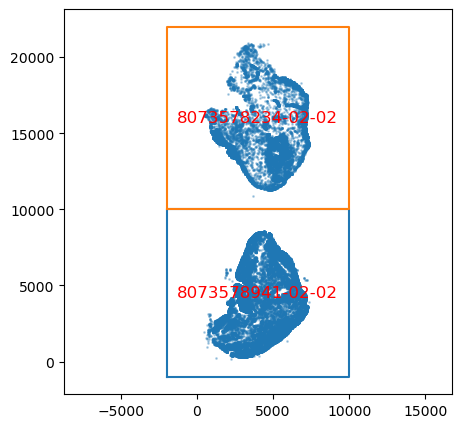

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [95]:
slide_id = 'slidearray0106'
s1 = Polygon([(-2000, -1000), (-2000, 10000), (10000, 10000), (10000, -1000)])
s1name = '8073578941-02-02'
s2 = Polygon([(-2000, 10000), (-2000, 22000), (10000, 22000), (10000, 10000)])
s2name = '8073578234-02-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0116
PsD


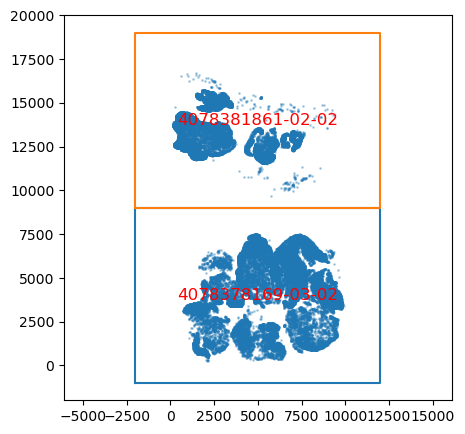

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [99]:
slide_id = 'slidearray0116'
s1 = Polygon([(-2000, -1000), (-2000, 9000), (12000, 9000), (12000, -1000)])
s1name = '4078378169-03-02'
s2 = Polygon([(-2000, 9001), (-2000, 19000), (12000, 19000), (12000, 9001)])
s2name = '4078381861-02-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

reading slidearray0118
PsD


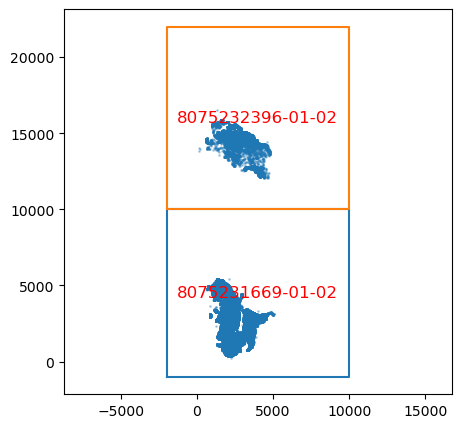

/PHShome/yr073/.conda/envs/geo/lib/python3.10/site-packages/pyogrio/geopandas.py:710: UserWarning:

'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.



In [101]:
slide_id = 'slidearray0118'
s1 = Polygon([(-2000, -1000), (-2000, 10000), (10000, 10000), (10000, -1000)])
s1name = '8075231669-01-02'
s2 = Polygon([(-2000, 10000), (-2000, 22000), (10000, 22000), (10000, 10000)])
s2name = '8075232396-01-02'
annotate(slide_id, [s1, s2], [s1name, s2name])

# Split into samples and QC transcripts and genes

## compute gene-level info, filter transcripts, and split samples

In [18]:
features = ['x_location', 'y_location', 'z_location', 'qv', 'nucleus_distance']

t0 = time.time()
os.makedirs('out/_gene_qc_metrics_edp1only', exist_ok=True)
nslides = len(metadata['Xenium-Slide_Sample_ID'].unique())
for i, slide_id in enumerate(metadata['Xenium-Slide_Sample_ID'].unique()):
    print(f'slide {i+1} of {nslides}, time: {time.time() - t0:.2f}')
    tx, subset, path = read(slide_id)
    print(subset)
    print(f'\t{len(tx)} transcripts')
    
    gene_info = tx[['feature_name']+features].groupby(by='feature_name').aggregate('mean')
    gene_info['ntranscripts'] = tx.feature_name.value_counts()
    gene_info['codeword_category'] = tx[['feature_name','codeword_category']].drop_duplicates().set_index('feature_name', drop=True).codeword_category
    gene_info['slide_id'] = slide_id
    gene_info.to_csv(f'out/_gene_qc_metrics_edp1only/{slide_id}.csv')

    targetdir = f'out/samples'
    os.makedirs(targetdir, exist_ok=True)
    boundaries = gpd.read_file(f'{xeniumdir}/Xenium_{subset}-SYN-EDP1/Level_2/xenium_bbox_synovium_{slide_id}.geojson')
    for sid, poly in zip(boundaries.sampleID, boundaries.geometry):
        inside = shapely.contains_xy(poly, tx.x_location.values, tx.y_location.values)
        sample = tx[inside]
        print(f'\twriting {sid} ({len(sample)} transcripts)')
        outdir = f'{targetdir}/{sid}'
        os.makedirs(outdir, exist_ok=True)
        sample.to_parquet(f'{outdir}/transcripts_txqc.parquet')
        del sample; gc.collect()
    del tx; gc.collect()

slide 1 of 17, time: 0.00
reading slidearray0104
CTRL
	73905460 transcripts
	writing 8073579095-02-02 (66799375 transcripts)
	writing 8073578341-02-02 (7106085 transcripts)
slide 2 of 17, time: 227.54
reading slidearray0106
CTRL
	38337989 transcripts
	writing 8073578941-02-02 (25677813 transcripts)
	writing 8073578234-02-02 (12660176 transcripts)
slide 3 of 17, time: 325.63
reading slidearray0081
RA
	63382361 transcripts
	writing 4078377935-02-02 (1739826 transcripts)
	writing 8073578511-02-02 (61642535 transcripts)
slide 4 of 17, time: 512.70
reading slidearray0083
RA
	181706751 transcripts
	writing 8073578284-02-02 (181706751 transcripts)
slide 5 of 17, time: 1080.91
reading slidearray0085
RA
	10651826 transcripts
	writing 4078381774-02-02 (3427217 transcripts)
	writing K0002-1301-05-02 (7224609 transcripts)
slide 6 of 17, time: 1111.59
reading slidearray0089
RA
	73405730 transcripts
	writing 4078380535-02-02 (73405730 transcripts)
slide 7 of 17, time: 1318.25
reading slidearray0091


In [6]:
gene_infos = pd.concat([pd.read_csv(f) for f in glob.glob(f'out/_gene_qc_metrics/*.csv')], ignore_index=True)
gene_infos.to_parquet('out/_gene_qc_metrics/all.parquet')